In [1]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Load the dataset
simulated_fake_transactional_dataset = pd.read_csv('../data/simulated_fake_transactions_dataset_2.csv')

In [3]:
# Gather information of the dataset
simulated_fake_transactional_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287791 entries, 0 to 287790
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    287510 non-null  object 
 1   Timestamp               287524 non-null  object 
 2   Account No              287480 non-null  float64
 3   Balance                 287506 non-null  float64
 4   Amount                  287482 non-null  float64
 5   Third Party Account No  8681 non-null    float64
 6   Third Party Name        278821 non-null  object 
dtypes: float64(4), object(3)
memory usage: 15.4+ MB


In [4]:
# Checking missing values
missing_values = simulated_fake_transactional_dataset.isnull().sum()
print("Missing Values:\n", missing_values)
duplicate_rows = simulated_fake_transactional_dataset.duplicated().sum()
print("Number of Duplicate Rows:", duplicate_rows)

Missing Values:
 Date                         281
Timestamp                    267
Account No                   311
Balance                      285
Amount                       309
Third Party Account No    279110
Third Party Name            8970
dtype: int64
Number of Duplicate Rows: 0


In [5]:
simulated_fake_transactional_dataset_clean = simulated_fake_transactional_dataset.dropna(subset=['Date','Timestamp','Account No','Balance','Amount','Third Party Name'])
df_clean = simulated_fake_transactional_dataset_clean.drop(columns=['Third Party Account No'])
print("Missing values:\n",df_clean.isnull().sum())
print("Shape of the dataset after dropping rows: ",df_clean.shape)

Missing values:
 Date                0
Timestamp           0
Account No          0
Balance             0
Amount              0
Third Party Name    0
dtype: int64
Shape of the dataset after dropping rows:  (277415, 6)


### Exploratory Data Analysis (EDA)

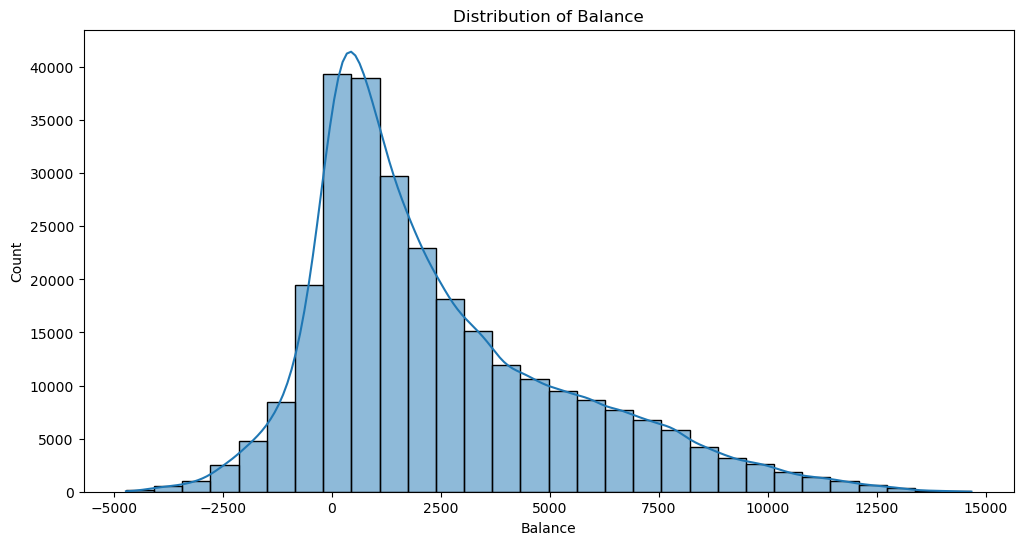

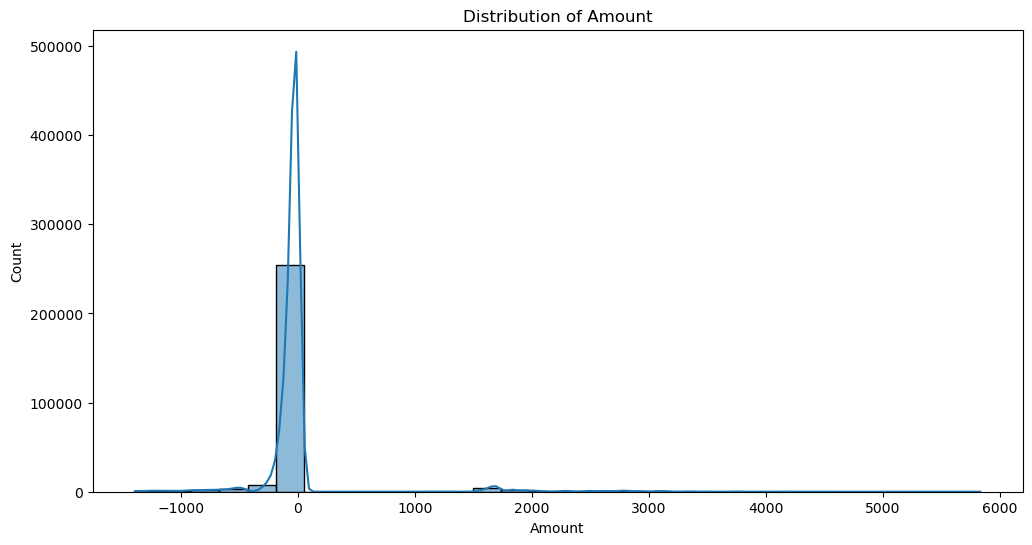

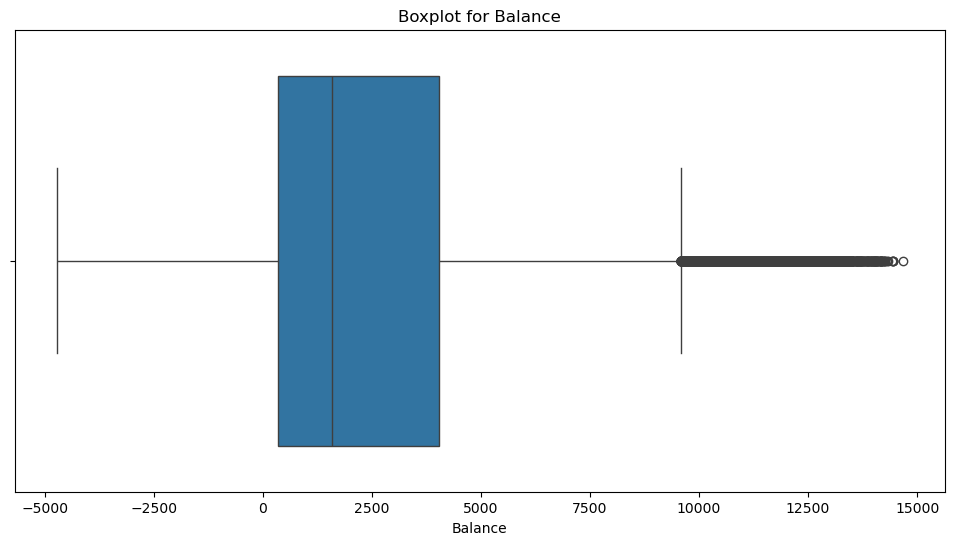

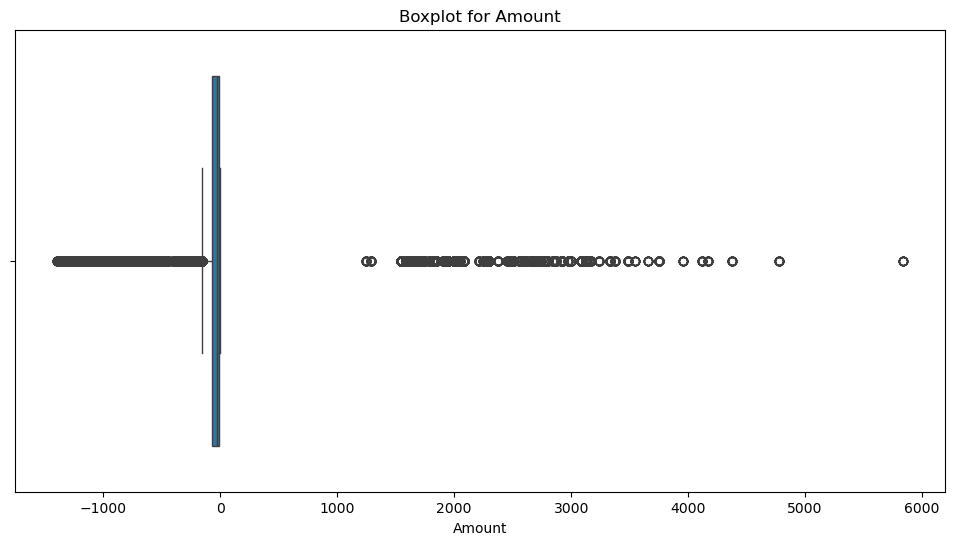

In [7]:
# Plotting histograms for key numerical features (Balance and Amount)
plt.figure(figsize = (12, 6))
sns.histplot(df_clean['Balance'], kde = True, bins = 30)
plt.title('Distribution of Balance')
plt.show()

plt.figure(figsize = (12, 6))
sns.histplot(df_clean['Amount'], kde = True, bins = 30)
plt.title('Distribution of Amount')
plt.show()

# Boxplot for Outlier Detection
plt.figure(figsize = (12, 6))
sns.boxplot(x = df_clean['Balance'])
plt.title('Boxplot for Balance')
plt.show()

plt.figure(figsize = (12, 6))
sns.boxplot(x = df_clean['Amount'])
plt.title('Boxplot for Amount')
plt.show()

**Balance Distribution**
* The balance data is **approximately normal**, but slightly skewed to the right.
* There are **siginificant outliers** on the **right**, menaing some accounts have extremely high balances compared to others.

**Amount Distribution**
* The transaction amounts are **highly skewed**, with most transactions **concentrated near zero**.
* The boxplot confirms **many extreme outliers**, indicating **a few large transactions among mostly small ones**.
* This suggests that the dataset may contain high-value transactions that could indicate high-net-worth individuals or businesses.

### Feature Engineering

In [10]:
# Converting Data and Timestamp to datetime format
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors = 'coerce', dayfirst = True)
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'], errors = 'coerce')

# checking if any values couldn't be converted
print("Missing Dates after conversion\n", df_clean['Date'].isna().sum())
print("Missing Timestamps after conversion:\n", df_clean['Timestamp'].isna().sum())

Missing Dates after conversion
 0
Missing Timestamps after conversion:
 0


C:\Users\snand\AppData\Local\Temp\ipykernel_3992\1734639040.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'], errors = 'coerce')


In [11]:
# Aggregating transaction data per customer
customer_summary = df_clean.groupby('Account No').agg(
    total_transaction_amount = ('Amount', 'sum'), # total amount transacted
    avg_transaction_amount = ('Amount', 'mean'), # average transaction amount
    transaction_count = ('Amount', 'count'), # total number of transactions
    avg_balance = ('Balance', 'mean'), # average balance per customer
    min_balance = ('Balance', 'min'), # minimum balance observed
    max_balance = ('Balance', 'max') # maximum balance observed
).reset_index()

# Extracting Time-based features
df_clean['Hour'] = df_clean['Timestamp'].dt.hour # extracting hour of the transaction
df_clean['Day'] = df_clean['Timestamp'].dt.day # extracting day of the transaction
df_clean['Month'] = df_clean['Timestamp'].dt.month # extracting month of the transaction

def get_mode(series):
    mode_values = series.mode()
    return int(mode_values.iloc[0]) if not mode_values.empty else np.nan
    
# Aggregating Time-based insights per customer
customer_time_summary = df_clean.groupby('Account No').agg(
    most_common_transaction_hour = ('Hour', get_mode),
    most_common_transaction_day = ('Day', get_mode),
    most_common_transaction_month = ('Month', get_mode)
).reset_index()

# convert time features into cyclical encoding
def encode_cyclical_feature(customer_time_summary, col, max_val):
    customer_time_summary[f'{col}_sin'] = np.sin(2 * np.pi * customer_time_summary[col] / max_val)
    customer_time_summary[f'{col}_cos'] = np.cos(2 * np.pi * customer_time_summary[col] / max_val)
    return customer_time_summary.drop(columns = [col])

# Merge transactions and time-based features
customer_features = pd.merge(customer_summary, customer_time_summary, on = 'Account No')

# Apply cyclical encoding
customer_time_summary = encode_cyclical_feature(customer_time_summary, 'most_common_transaction_day', 31)
customer_time_summary = encode_cyclical_feature(customer_time_summary, 'most_common_transaction_hour', 24)
customer_time_summary = encode_cyclical_feature(customer_time_summary, 'most_common_transaction_month', 12)

# Saving the processed data to a csv file
customer_features.to_csv('customer_features.csv', index = False)

# Display first few rows of the processed data
customer_features.head()

,Account No,total_transaction_amount,avg_transaction_amount,transaction_count,avg_balance,min_balance,max_balance,most_common_transaction_hour,most_common_transaction_day,most_common_transaction_month
0,100100738.0,-8546.91,-67.298504,127,-155.018778,-1259.733078,1010.010000,9,19,3
1,100837224.0,-6590.23,-67.247245,98,-57.863997,-744.681300,560.010000,23,19,3
2,101348775.0,2773.78,6.233213,445,3563.614577,43.302650,5452.374061,6,19,3
3,103439190.0,12173.33,22.336385,545,10196.103150,2893.060940,13532.368459,6,19,3
4,104009728.0,7009.07,15.893583,441,5850.939977,-511.579000,9368.873410,23,19,3


### Data Preprocessing for Clustering

In [13]:
# Handling negative transaction amounts (convert to absolute values if necessary)
customer_features['total_transaction_amount'] = customer_features['total_transaction_amount'].abs()
customer_features['avg_transaction_amount'] = customer_features['avg_transaction_amount'].abs()

# Scaling the data using StandardScaler
scaler = StandardScaler()
numeric_columns = ['total_transaction_amount', 'avg_transaction_amount', 'transaction_count', 'avg_balance', 'min_balance', 'max_balance']
customer_features_scaled = customer_features.copy()
customer_features_scaled[numeric_columns] = scaler.fit_transform(customer_features[numeric_columns])

# Saving the processed and scaled data to another csv file
customer_features_scaled.to_csv('customer_features_scaled.csv', index = False)

# Display first few rows of the processed and scaled data
customer_features_scaled.head()

,Account No,total_transaction_amount,avg_transaction_amount,transaction_count,avg_balance,min_balance,max_balance,most_common_transaction_hour,most_common_transaction_day,most_common_transaction_month
0,100100738.0,0.206702,0.810221,-0.820572,-0.697191,-0.448877,-0.920554,9,19,3
1,100837224.0,-0.128958,0.808699,-1.053259,-0.655738,-0.071181,-1.063751,23,19,3
2,101348775.0,-0.783653,-1.002298,1.730962,0.889427,0.506662,0.493078,6,19,3
3,103439190.0,0.828798,-0.524329,2.533332,3.719290,2.596440,3.064262,6,19,3
4,104009728.0,-0.057108,-0.715562,1.698868,1.865353,0.099757,1.739371,23,19,3


### Implementing Elbow Method and Silhoutte Score

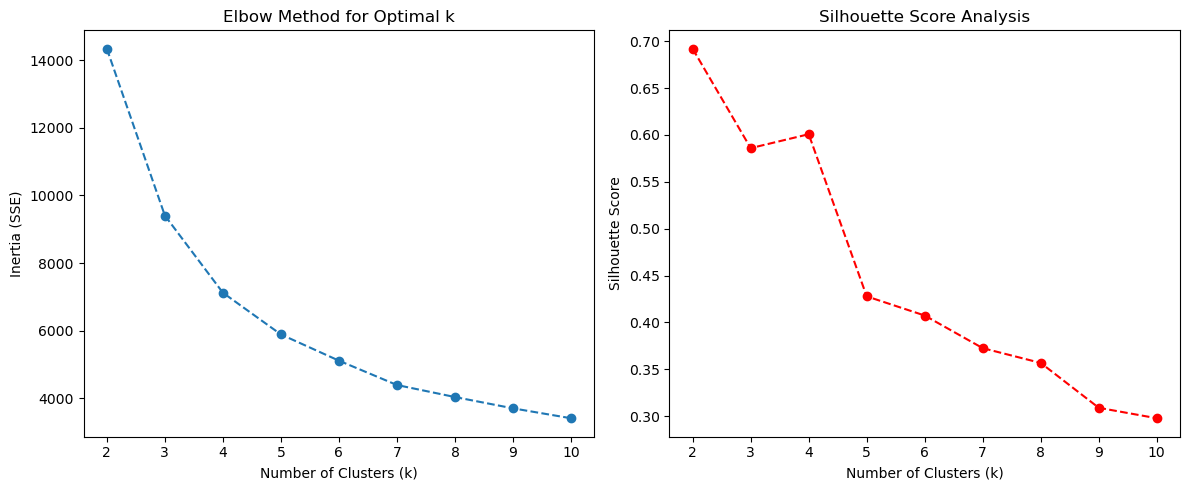

In [15]:
# cSelecting features for clustering (excluding Account No)
clustering_features = customer_features_scaled.drop(columns = ['Account No'])

# Range of clusters to test
k_values = range(2, 11)
inertia = [] # for the Elbow Method
silhouette_scores = [] # for silhoutte score

# looping through different k values
for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(clustering_features)
    inertia.append(kmeans.inertia_) # sum of squared distances to cluster center
    silhouette_scores.append(silhouette_score(clustering_features, labels)) # measure of clustering quality

# Plot Elbow Method
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method for Optimal k')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker = 'o', linestyle = '--', color = 'red')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis')

plt.tight_layout()
plt.show()

**Elbow Plot**
* The inertia decreases up to **k = 3 or 4**, after which the decline goes down rapdily.
* The "elbow" appears around **k = 4 or 5**, indicating the optimal number of clusters where adding more clusters gives diminishing returns.

**Silhouette Score**
* The silhouette score is highest at **k = 2 or 3**, meaning the clusters are well-defined at these points.
* However, it starts to decline significantly beyond **k = 4 or 5**, indicating that adding more clusters reduces cluster cohesion.

### KMeans Clustering

In [18]:
# Applying K-Means with k = 4
kmeans = KMeans(n_clusters = 4, random_state = 42, n_init = 10)
customer_features_scaled['KMeans_Cluster'] = kmeans.fit_predict(clustering_features)

# Checking cluster distribution
cluster_counts = customer_features_scaled['KMeans_Cluster'].value_counts().sort_index()
print("Cluster count:\n", cluster_counts)

Cluster count:
 KMeans_Cluster
0    147
1    795
2    233
3     35
Name: count, dtype: int64


In [19]:
# Evaluting KMean Clustering
silhouette_kmeans = silhouette_score(customer_features_scaled.drop(columns = ['KMeans_Cluster']), customer_features_scaled['KMeans_Cluster'])
davies_kmeans = davies_bouldin_score(customer_features_scaled.drop(columns = ['KMeans_Cluster']), customer_features_scaled['KMeans_Cluster'])

print(f"KMeans Clustering Silhouette Score: {silhouette_kmeans}")
print(f"KMeans Clustering Davies-Bouldin Index: {davies_kmeans}")

KMeans Clustering Silhouette Score: -0.08995091461446578
KMeans Clustering Davies-Bouldin Index: 46.64240760263022


### DBSCAN Clustering

In [21]:
for eps_val in [0.3, 0.5, 0.7, 1.0]:
    for min_samples_val in [3, 5, 10]:
        dbscan = DBSCAN(eps = eps_val, min_samples = min_samples_val)
        labels = dbscan.fit_predict(customer_features_scaled)
        unique_labels = np.unique(labels)
        print(f"eps={eps_val}, min_samples={min_samples_val} -> Unique Clusters: {unique_labels}")

eps=0.3, min_samples=3 -> Unique Clusters: [-1]
eps=0.3, min_samples=5 -> Unique Clusters: [-1]
eps=0.3, min_samples=10 -> Unique Clusters: [-1]
eps=0.5, min_samples=3 -> Unique Clusters: [-1]
eps=0.5, min_samples=5 -> Unique Clusters: [-1]
eps=0.5, min_samples=10 -> Unique Clusters: [-1]
eps=0.7, min_samples=3 -> Unique Clusters: [-1]
eps=0.7, min_samples=5 -> Unique Clusters: [-1]
eps=0.7, min_samples=10 -> Unique Clusters: [-1]
eps=1.0, min_samples=3 -> Unique Clusters: [-1]
eps=1.0, min_samples=5 -> Unique Clusters: [-1]
eps=1.0, min_samples=10 -> Unique Clusters: [-1]


Since all the results are returning a value of **-1**.
<br>
Conclustion: This is **not working** well for this dataset!

### Hierarchical Clustering

In [24]:
hierarchical = AgglomerativeClustering(n_clusters = 4) # assuming 4 clusters based on previous analysis
customer_features_scaled['Hierarchical_Cluster'] = hierarchical.fit_predict(customer_features_scaled)

# Evaluate Hierarchical Clustering
silhouette_hierarchical = silhouette_score(customer_features_scaled.drop(columns = ['Hierarchical_Cluster']), customer_features_scaled['Hierarchical_Cluster'])
davies_hierarchical = davies_bouldin_score(customer_features_scaled.drop(columns = ['Hierarchical_Cluster']), customer_features_scaled['Hierarchical_Cluster'])

print(f"Hierarchical Clustering Silhouette Score: {silhouette_hierarchical}")
print(f"Hierarchical Clustering Davies-Bouldin Index: {davies_hierarchical}")

Hierarchical Clustering Silhouette Score: 0.5579538434742647
Hierarchical Clustering Davies-Bouldin Index: 0.5085702945791286


* **Silhouette Score** *0.5579* is a **moderately high score**, indicating the clusters are well-separated and distinct.
* **Davies-Bouldin** *0.5085* Index suggests that the clusters are **compact and well-separated** which is good sign based on the lower DB Index

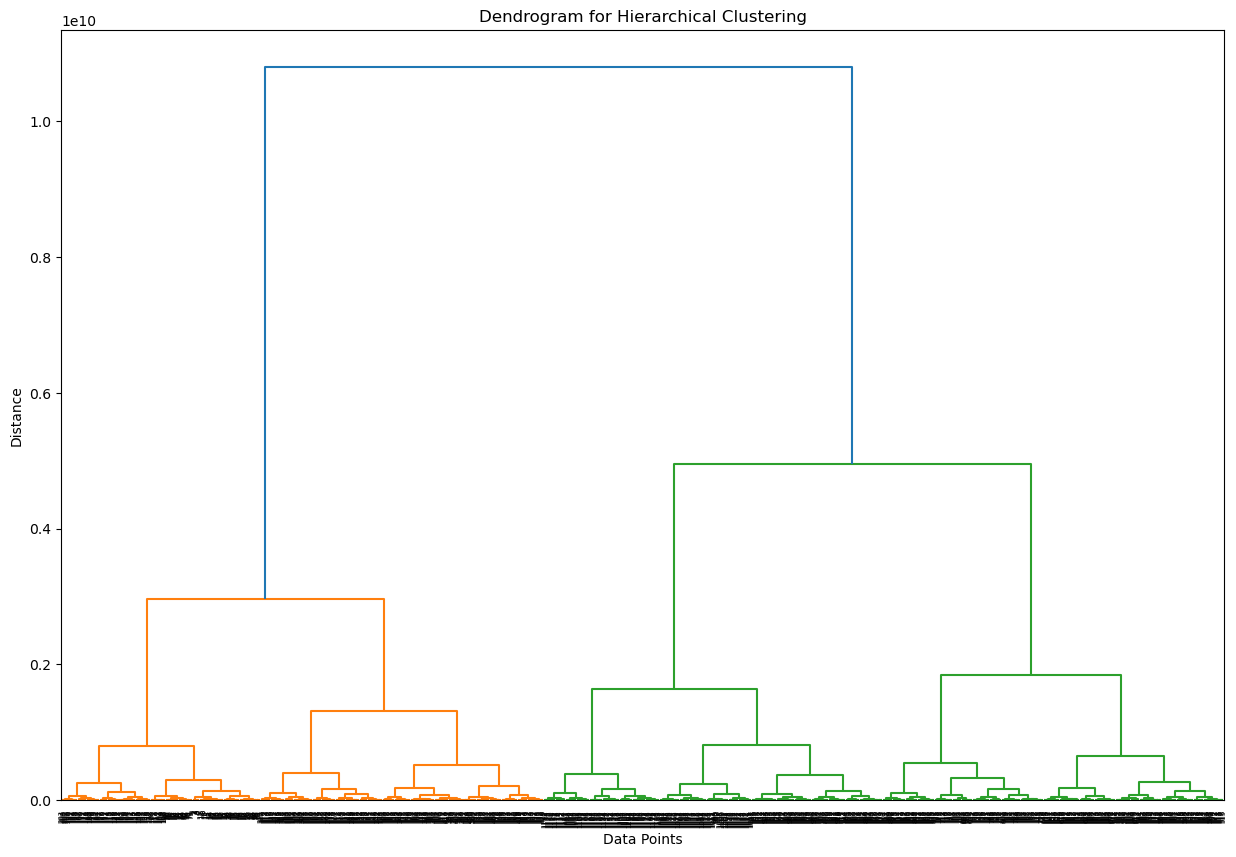

In [26]:
# Plotting Dendogram for Hierarchical Clustering
plt.figure(figsize = (15, 10))
linkage_matrix = linkage(customer_features_scaled.drop(columns = ['Hierarchical_Cluster']), method = 'ward')
dendrogram(linkage_matrix)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Gaussian Mixture Model (GMM)

In [28]:
gmm = GaussianMixture(n_components = 4, random_state = 42) # assuming 4 clusters
customer_features_scaled['GMM_Cluster'] = gmm.fit_predict(customer_features_scaled.drop(columns = ['Hierarchical_Cluster']))

# Evaluate Hierarchical Clustering
silhouette_gmm = silhouette_score(customer_features_scaled.drop(columns = ['Hierarchical_Cluster', 'GMM_Cluster']), customer_features_scaled['GMM_Cluster'])
davies_gmm = davies_bouldin_score(customer_features_scaled.drop(columns = ['Hierarchical_Cluster', 'GMM_Cluster']), customer_features_scaled['GMM_Cluster'])

print(f"GMM Clustering Silhouette Score: {silhouette_gmm}")
print(f"GMM Clustering Davies-Bouldin Index: {davies_gmm}")

GMM Clustering Silhouette Score: -0.05011156518981506
GMM Clustering Davies-Bouldin Index: 33.28791366885295


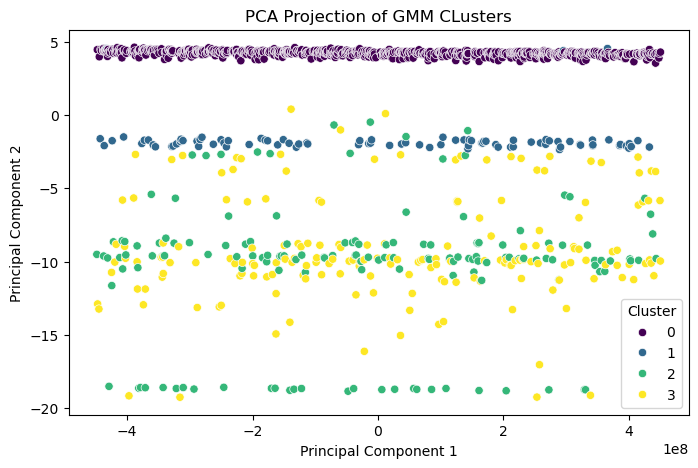

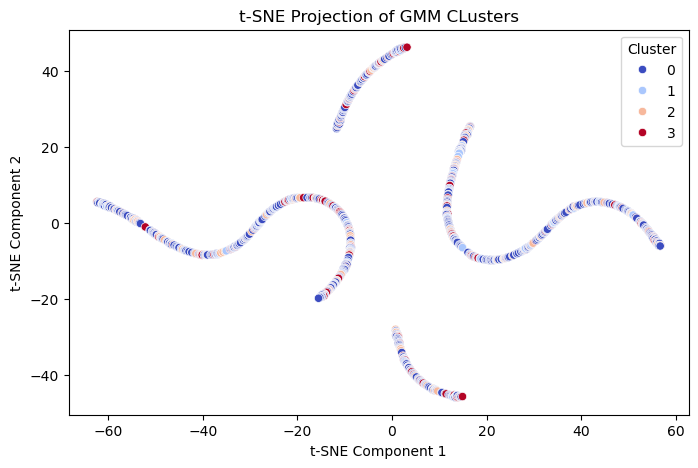

In [29]:
# Plotting PCA and t-SNE for GMM
# PCA Visualisation
pca = PCA(n_components = 2)
customer_pca = pca.fit_transform(customer_features_scaled.drop(columns = ['Hierarchical_Cluster', 'GMM_Cluster']))
plt.figure(figsize = (8, 5))
sns.scatterplot(x = customer_pca[:, 0], y = customer_pca[:, 1], hue = customer_features_scaled['GMM_Cluster'], palette = 'viridis')
plt.title("PCA Projection of GMM CLusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title = "Cluster")
plt.show()

#t-SNE Visualisation
tsne = TSNE(n_components = 2, random_state = 42)
customer_tsne = tsne.fit_transform(customer_features_scaled.drop(columns = ['Hierarchical_Cluster', 'GMM_Cluster']))
plt.figure(figsize = (8, 5))
sns.scatterplot(x = customer_tsne[:, 0], y = customer_tsne[:, 1], hue = customer_features_scaled['GMM_Cluster'], palette = 'coolwarm')
plt.title("t-SNE Projection of GMM CLusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title = "Cluster")
plt.show()

* **Silhouette Score** *-0.0607* A negative score indicated that many points are assigned to **wrong clusters** or that the clusters are heavily overlapping and this can be confirmed from our plots.
* **Davies Bouldin Index** *44.7331* A **very high DB index** suggests **poorly separated clusters**, meaning GMM is struggling to form distinct clusters.
* Conclusion: GMM is **not a good fit** for this dataset!

### Best Clustering Model Selection

| Clustering Method | Silhouette Score (higher is better) | Davies-Bouldin Index (lower is better) |
|-------------------|-------------------------------------|----------------------------------------|
| K-Means           | -0.0899 (Poor)                      | 46.64 (Very Poor)                      |
| Hierarchical      | 0.5579 (Best)                       | 0.5085 (Best)                          |
| GMM               | -0.0606 (Poor)                      | 44.73 (Very Poor)                      |
| DBSCAN            | Failed (returned -1)                | Failed                                 |

**Inference**:
* **Hierarchical Clustering** is the best model based on **both metrics**.

**Decision**: Proceeding with Hierarchical Clustering for customer segmentation

## Visualising Customer Segmentation Results

### Visualising Cluster Distribution

C:\Users\snand\AppData\Local\Temp\ipykernel_3992\3334695578.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = cluster_counts.index, y = cluster_counts.values, palette = 'viridis')


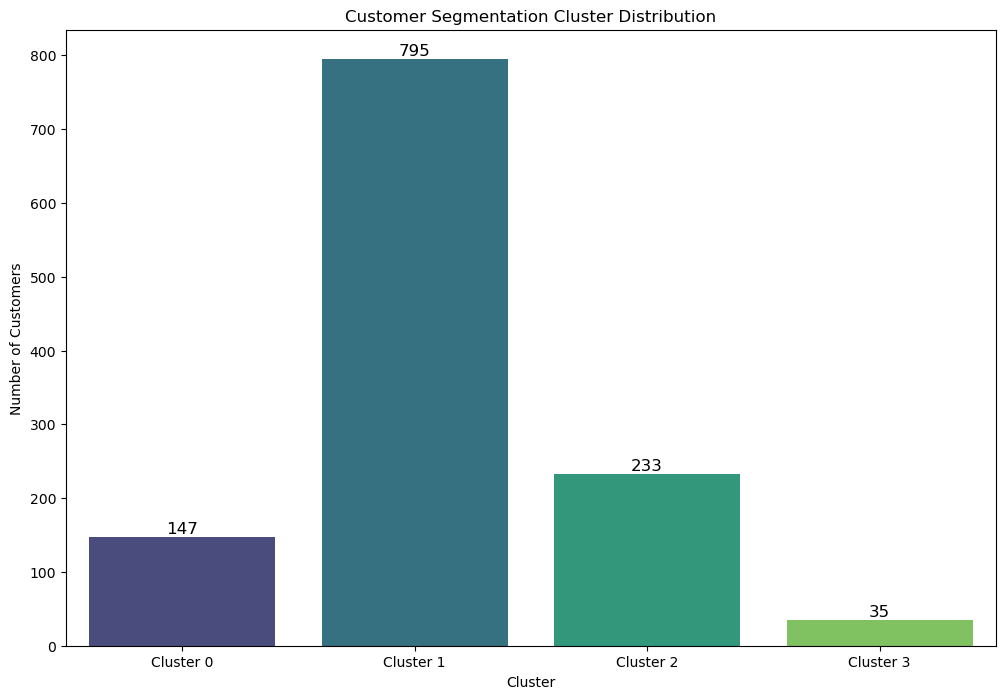

In [34]:
# Plotting the cluster distribution
plt.figure(figsize = (12, 8))
sns.barplot(x = cluster_counts.index, y = cluster_counts.values, palette = 'viridis')

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Segmentation Cluster Distribution')
plt.xticks(ticks = range(4), labels = [f'Cluster {i}' for i in range(4)])

# Show value on bars
for i, count in enumerate(cluster_counts.values):
    plt.text(i, count + 5, str(count), ha = 'center', fontsize = 12)

plt.show()

### PCA for Dimensionality Reduction & Visualisation

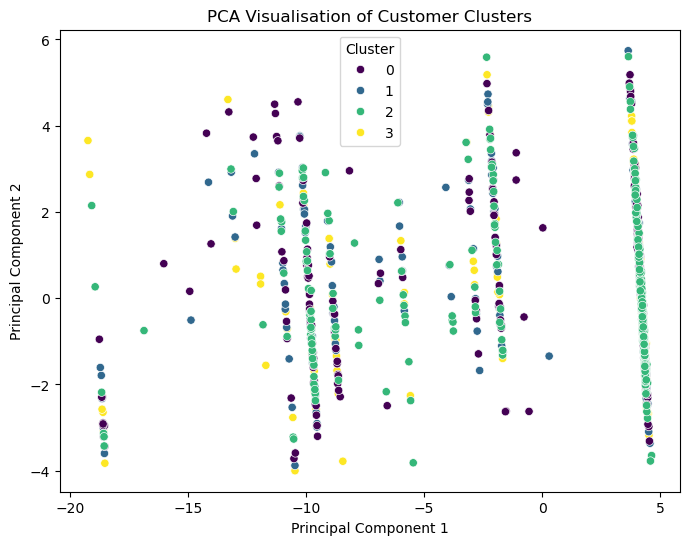

In [36]:
# Apply PCA to reduce dimensionality to 2D
pca = PCA(n_components = 2)
pca_result = pca.fit_transform(clustering_features)

# Convert PCA result into DataFrame
customer_features_scaled['PCA1'] = pca_result[:, 0]
customer_features_scaled['PCA2'] = pca_result[:, 1]

# Plot PCA Clusters
plt.figure(figsize = (8, 6))
sns.scatterplot(x = 'PCA1', y = 'PCA2', hue = 'Hierarchical_Cluster', data = customer_features_scaled, palette = 'viridis')

plt.title("PCA Visualisation of Customer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title = "Cluster")
plt.show()

* The data points appear **vertically aligned**, which indicated **high variance in one principal component** but **limited separation** in another.
* Clusters **overlap**, suggesting that some features may not contribute significantly to segmentation.

### t-SNE for Cluster Visualisation

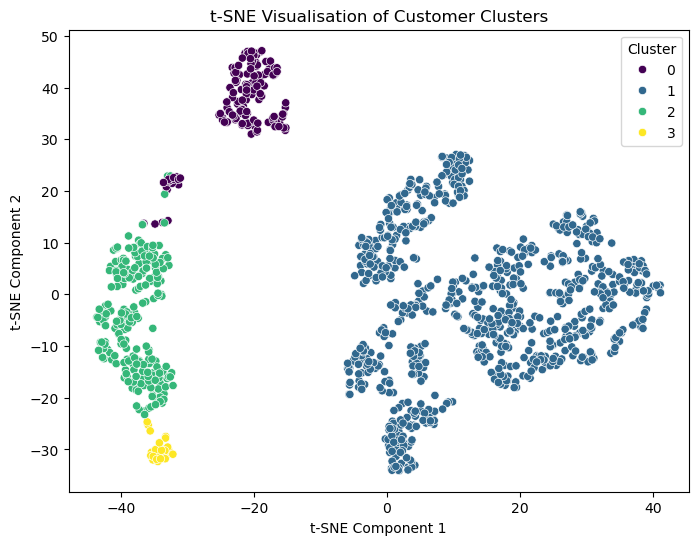

In [39]:
# Apply t-SNE for better separation
tsne = TSNE(n_components = 2, perplexity = 30, random_state = 42)
tsne_result = tsne.fit_transform(clustering_features)

# Add cluster labels
customer_features_scaled['Cluster'] = kmeans.labels_

# Add t-SNE results
customer_features_scaled['TSNE1'] = tsne_result[:, 0]
customer_features_scaled['TSNE2'] = tsne_result[:, 1]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='Cluster',
    data=customer_features_scaled,
    palette='viridis'
)

plt.title("t-SNE Visualisation of Customer Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title = "Cluster")
plt.show()

The **t-SNE visualisation shows well-separated clusters**, which confirms that the **Hierarchical Clustering method was effective**. Unlike PCA (which showed overlapping clusters), t-SNE helps capture **non-linear relationships** in the data. 

**Key Observations**
* **Cluster 0 (Dark blue) is the largest group**, spread across a wide range, indicating **diverse customer behaviors** within this segment.
* **Cluster 1 (Purple) is compact and isolated**, suggesting a **unique segment** with distinct transactional behavior.
* **Cluster 2 (Green) & Cluster 3 (Yellow) are close together**, meaning they  may have **some common characteristics**, but Cluster is still somewhat distinct.

### Cluster Profiling 
Understanding Each Cluster's Characteristics

In [43]:
# Cluster Profiling: compute mean values for each feature per cluster
cluster_profile = customer_features_scaled.groupby('Hierarchical_Cluster').mean()

# Display the profiling summary
print(cluster_profile)

                        Account No  total_transaction_amount  \
Hierarchical_Cluster                                           
0                     6.023320e+08                  0.043962   
1                     3.659758e+08                 -0.020040   
2                     8.654734e+08                 -0.050390   
3                     1.763657e+08                  0.039096   

                      avg_transaction_amount  transaction_count  avg_balance  \
Hierarchical_Cluster                                                           
0                                  -0.012596           0.061311     0.100836   
1                                  -0.016428           0.021481    -0.016386   
2                                  -0.003243          -0.066504    -0.032898   
3                                   0.050543          -0.022350    -0.093478   

                      min_balance  max_balance  most_common_transaction_hour  \
Hierarchical_Cluster                                  

### Inference:
| Cluster | Transaction Amount | Avg Transaction Amount | Transaction Count | Avg Balance | Most Common Transaction Hour | Inference |
|---------|--------------------|------------------------|-------------------|-------------|------------------------------|-----------|
| **0** | Moderate (0.04) | Slightly Negative (-0.012) | Medium (0.06) | High (0.10) | **Evening (18.5h)** | **High-value, frequent transactions** |
| **1** | Slightly Lower (-0.02) | Negative (-0.016) | Medium (0.02) | Low (-0.016) | **Evening (18.9h)** | **Moderate engagement, low balance** |
| **2** | Lower (-0.05) | Slightly Negative (-0.003) | Fewer (-0.06) | Lower (-0.032) | **Night (19.0h)**| **Low engagement customers** |
| **3** | Moderate (0.04) | Positive (0.05) | Fewer (-0.02) | Lowest (-0.093) | **Evening (18.7h)** | **Occasional high-value spenders** |

### Business Insights
* **Cluster 0 - High-Value Frequent Customers**
  * **Loyal Customers**: High balance, high transactions, but not the largest total spend.
  * **Strategy**: Offer **premium benefits, VIP perks**, or **personalised offers** to retain them.
<br><br> 
* **Cluster 1 - Moderate Engagement, Low Balance**
  * **Average transactions, lower balance.**
  * **Strategy**: Encourage more transactions through **discount-based incentives** or **loyalty programs**.
<br><br>
* **Cluster 2 - Low Engagement, Minimal Transactions**
  * **Lower transaction counts, lower balances**.
  * **Strategy**: Reactivation campaign with **targeted promotions**, reminders, and **subscription plans**.
<br><br>
* **Cluster 3 - Occasional High-Value Customers**
  * **Higher transaction amount but fewer transactions**.
  * **Strategy**: Offer **exclusive deals** during peak hours when they transact (evening).